In [1]:
user_id = "tp99965073"
domain = "AXISB.COM"
app_name = "Fraud_&_AML"
yarn_queue = "root.DEV.AML_FRAUD_CS"

EXECUTOR_MEMORY=28
EXECUTOR_CORE=4

INITIAL_EXECUTORS=8
MAX_EXECUTORS=50     # 16x4 = 64 cores; lower this to your approved cap if smaller (YARN grants only what is free)
MIN_EXECUTORS=2

In [2]:
import sys
from pyspark.sql import SparkSession, SQLContext
from pyspark import SparkContext, SparkConf
from pyspark.sql import functions as F
from pyspark.sql import Window as W
import pyspark.sql.types as T
from datetime import datetime, date,timedelta
from dateutil.relativedelta import relativedelta
import pandas as pd
import time
import numpy as np


from IPython.core.display import HTML
display(HTML("<style>pre { white-space: pre !important; }</style>"))


# Construct the keytab path and the principal
keytab_path = f"/home/{user_id}@axisb.com/{user_id}.keytab"
principal = f"{user_id}@{domain}"

# Execute the commands
!kdestroy
!kinit -k -t "{keytab_path}" {principal}
try:
    spark.stop()
    print("Existing Spark Session Killed")
except:
    print("")
print("Creating new spark session since: ", datetime.now())
spark = SparkSession\
    .builder\
    .appName(f'JH_{user_id}_{app_name}')\
    .config('spark.sql.execution.arrow.enabled', "true")\
    .config('spark.master','yarn')\
    .config('spark.deploy-mode', 'cluster')\
    .config("spark.principal",f"{user_id}@AXISB.COM") \
    .config("spark.keytab",f"{user_id}.keytab")\
    .config('spark.dynamicAllocation.enabled','true') \
    .config('spark.dynamicAllocation.minExecutors',MIN_EXECUTORS) \
    .config('spark.dynamicAllocation.initialExecutors',INITIAL_EXECUTORS) \
    .config('spark.dynamicAllocation.maxExecutors',MAX_EXECUTORS) \
    .config('spark.executor.cores',EXECUTOR_CORE) \
    .config('spark.dynamicAllocation.executorAllocationRatio','0.8')\
    .config('spark.executor.memory',f'{EXECUTOR_MEMORY}g')\
    .config('spark.driver.memory','16g')\
    .config('spark.driver.cores','1')\
    .config('spark.executor.memoryOverhead','8g')\
    .config('spark.sql.shuffle.partitions','12000')\
    .config('spark.shuffle.service.enabled','true')\
    .config('spark.network.timeout','600s')\
    .config('spark.shuffle.io.maxRetries','10')\
    .config('spark.shuffle.io.retryWait','15s')\
    .config('spark.stage.maxConsecutiveAttempts','8')\
    .config('spark.maxRemoteBlockSizeFetchToMem','512m')\
    .config("spark.sql.broadcastTimeout", "-1")\
    .config("spark.sql.parquet.int96RebaseModeInRead", "LEGACY")\
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY")\
    .config("spark.sql.parquet.int96RebaseModeInRead", "CORRECTED")\
    .config("spark.sql.parquet.int96RebaseModeInWrite", "CORRECTED")\
    .config("spark.sql.parquet.datetimeRebaseModeInRead", "CORRECTED")\
    .config("spark.sql.parquet.datetimeRebaseModeInWrite", "CORRECTED")\
    .config("spark.yarn.queue", yarn_queue)\
    .config('spark.sql.sources.partitionOverwriteMode', 'dynamic')\
    .config('spark.hadoop.hive.exec.dynamic.partition.mode', 'nonstrict')\
    .config('spark.sql.parquet.output.committer.class', 'org.apache.parquet.hadoop.ParquetOutputCommitter')\
    .config('spark.sql.sources.commitProtocolClass', 'org.apache.spark.sql.execution.datasources.SQLHadoopMapReduceCommitProtocol')\
    .config("spark.jars", "hdfs:///jars/iceberg-spark-runtime-3.3_2.12-1.6.1.jar,/opt/cloudera/parcels/CDH/jars/ojdbc8.jar")\
    .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions')\
    .config('spark.sql.catalog.spark_catalog', 'org.apache.iceberg.spark.SparkSessionCatalog')\
    .config('spark.sql.catalog.spark_catalog.type', 'hive')\
    .config('spark.sql.adaptive.enabled', 'true')\
    .config('spark.sql.adaptive.coalescePartitions.enabled', 'true')\
    .config('spark.sql.adaptive.skewJoin.enabled', 'true')\
    .config('spark.sql.adaptive.autoBroadcastJoinThreshold','50MB')\
    .config("spark.sql.legacy.allowNonEmptyLocationInCTAS", "true")\
    .enableHiveSupport()\
    .getOrCreate()
sc = SparkContext.getOrCreate()
print("New Spark Session created at : ", datetime.now())

new_log_level = "ERROR"
sc.setLogLevel(new_log_level)
print(f"Logs level set to {new_log_level}")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)


Creating new spark session since:  2026-07-08 08:15:04.874680


26/07/08 08:15:05 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
26/07/08 08:15:05 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/08 08:15:06 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
26/07/08 08:15:06 WARN  spark.SparkConf: [Thread-10]: The configuration key 'spark.maxRemoteBlockSizeFetc

New Spark Session created at :  2026-07-08 08:15:19.022133
Logs level set to ERROR


# Notebook 07 (v2) — SUPERVISED WOE-logistic scorecard (a LEARNED combiner over the leak-free features)

06 blended the selected features with an **equal-weight percent-rank sum** — transparent, but it can't learn
that (say) `n_shared_mule` deserves more weight than `n_shared_atm`, nor capture interactions. This notebook
replaces the hand-blend with the canonical bank/BIU model: **Weight-of-Evidence binning + a regularised
logistic-regression scorecard.** It answers one question directly: *how much headroom is left in the features
we already have, once a model is allowed to weight them optimally?*

**Why a WOE-logistic scorecard and NOT a GBM/black-box:** there are only ~250 fraud customers across the three
anchors. A gradient-boosted model would overfit that; a regularised logistic on a curated, non-collinear
feature set is interpretable (per-feature coefficients + points), monotone via WOE, and is exactly the
`Binning.ipynb` scorecard methodology the mentor uses. L2 shrinkage handles the small-sample risk.

**Leak-free discipline:** WOE bins AND logistic coefficients are fit on the MATURE TRAIN anchors only
(Sep+Oct); Nov (immature labels) is a held-out read. `target_fraud` is used only to fit/evaluate — never as an
input. Reads 06's `_v2_final_features` (all candidate features already joined). No new graph computation — this
is a driver-side model on the tiny customer table. Run AFTER 04/04b/05/06. Session cells first, top to bottom.


In [3]:
# ---- PARAMETERS ----
from pyspark.sql import functions as F
from pyspark.sql import Window
import numpy as np
import pandas as pd

WRITE_DB = "payment_cards_dev"; EMP = "TP99965073"
IN_FEATURES = f"{WRITE_DB}.{EMP}_v2_final_features"      # nb 06: master joined leak-free features + target_fraud

# Curated, non-collinear, leak-free feature set for the scorecard. We deliberately DROP collinear twins
# (ring_co_feeders / max_shared_mule_fanin ~ n_shared_mule; block_density ~ in_dense_block) and dead features
# (cycles). `ppr` is INCLUDED on purpose so you can watch L2 shrink its coefficient toward 0 (it is redundant
# with closeness) — the model makes the "ppr is weak" conclusion quantitative.
FEATURES = ["n_shared_mule", "closeness_to_bad", "n_shared_atm", "comm_bad_rate", "fraudar_score",
            "in_dense_block", "ppr"]

TRAIN_ANCHORS = ["202509", "202510"]   # fit WOE + logistic on the MATURE anchors; Nov is a held-out read
K_PCTS   = [0.01, 0.05, 0.10]
MAX_BINS = 8                           # WOE bins per feature (zero-inflation-safe binner)
L2_LAMBDA = 2.0                        # ridge strength on the logistic (small sample -> shrink hard)
IRLS_ITERS = 30
RULE_FEATURES = ["in_dense_block", "n_shared_atm", "n_shared_mule"]

OUT_WOE    = f"{WRITE_DB}.{EMP}_v2_scorecard_woe"        # per-feature per-bin WOE + IV (the scorecard bins)
OUT_COEF   = f"{WRITE_DB}.{EMP}_v2_scorecard_coef"       # fitted coefficients + IV per feature
OUT_SCORES = f"{WRITE_DB}.{EMP}_v2_scorecard_scores"     # cust, anchor, target, model_score, risk_pctl
OUT_VALID  = f"{WRITE_DB}.{EMP}_v2_scorecard_validation" # capture@K: MODEL vs 06-blend vs 04-core

spark.conf.set("spark.sql.shuffle.partitions", "256")

def save_overwrite(df, t):
    spark.sql("DROP TABLE IF EXISTS " + t); df.write.mode("overwrite").saveAsTable(t)

print("scorecard | features:", FEATURES, "| train:", TRAIN_ANCHORS, "| L2:", L2_LAMBDA, "| bins:", MAX_BINS)


scorecard | features: ['n_shared_mule', 'closeness_to_bad', 'n_shared_atm', 'comm_bad_rate', 'fraudar_score', 'in_dense_block', 'ppr'] | train: ['202509', '202510'] | L2: 2.0 | bins: 8


## A. Load to pandas (tiny) + validation harness (capture@K, percent-rank for the 06-blend comparison)


In [4]:
pdf = spark.table(IN_FEATURES).select("cust", "anchor_month", "target_fraud", *FEATURES).toPandas()
pdf["target_fraud"] = pdf["target_fraud"].fillna(0).astype(int)
for c in FEATURES:
    pdf[c] = pd.to_numeric(pdf[c], errors="coerce").fillna(0.0)
ANCHORS = sorted(pdf["anchor_month"].unique().tolist())
TRAIN = [a for a in TRAIN_ANCHORS if a in ANCHORS] or ANCHORS
tr_mask = pdf["anchor_month"].isin(TRAIN).values
print("frame:", pdf.shape, "| anchors:", ANCHORS, "| train:", TRAIN,
      "| bad by anchor:", {a: int(pdf.loc[pdf.anchor_month == a, "target_fraud"].sum()) for a in ANCHORS})

def capture_at_pd(y, score, ks):
    y = np.asarray(y, dtype=int); score = np.asarray(score, dtype=float)
    order = np.argsort(-score, kind="mergesort"); ys = y[order]; n = len(y); nbad = int(y.sum()); rows = []
    for p in ks:
        K = max(1, int(n * p)); topbad = int(ys[:K].sum())
        cap = (topbad / nbad) if nbad else 0.0
        lift = ((topbad / K) / (nbad / n)) if nbad else 0.0
        rows.append((p, K, topbad, cap, lift))
    return rows, n, nbad

def _pctrank_group(s):
    n = len(s)
    if n <= 1: return pd.Series(np.zeros(n), index=s.index)
    return (s.rank(method="min") - 1.0) / (n - 1.0)   # matches Spark percent_rank; zero-mass -> 0


Hive Session ID = 85c107b7-c85b-4b7d-9ca6-a10c28e0c47a
[Stage 0:=======================================================> (31 + 1) / 32]

frame: (183286, 10) | anchors: ['202509', '202510', '202511'] | train: ['202509', '202510'] | bad by anchor: {'202509': 97, '202510': 95, '202511': 54}


## B. WOE binning — FIT on train anchors, TRANSFORM all rows (fit/transform, no leakage)
For each feature: a zero-inflation-safe binner (dedicated 0 bin + quantile edges on the non-zero tail, or one
bin per value for low-cardinality counts). WOE per bin = ln(%bad / %good) computed on TRAIN only (higher WOE =
riskier); unseen bins map to WOE 0 (neutral). IV = sum over bins of (%bad - %good) * WOE — scorecard strength.


In [5]:
def fit_bins(x, max_bins=MAX_BINS):
    s = pd.Series(np.asarray(x, dtype=float)); nuniq = int(s.nunique(dropna=True))
    if nuniq <= 1:
        return {"kind": "const"}
    if nuniq <= max_bins:                                       # low-cardinality counts / binary -> one bin per value
        return {"kind": "cat", "vals": sorted(s.dropna().unique().tolist())}
    nz = s[s != 0]
    if (s == 0).mean() >= 0.02 and len(nz) >= max_bins:         # zero-inflated -> bin 0 = zeros, quantiles on the tail
        edges = np.unique(np.quantile(nz, np.linspace(0, 1, max_bins)))
        return {"kind": "zeroq", "edges": edges}
    edges = np.unique(np.quantile(s, np.linspace(0, 1, max_bins + 1)))
    return {"kind": "q", "edges": edges}

def apply_bins(x, spec):
    x = np.asarray(x, dtype=float)
    if spec["kind"] == "const":
        return np.zeros(len(x), dtype=int)
    if spec["kind"] == "cat":
        m = {v: i for i, v in enumerate(spec["vals"])}
        return np.array([m.get(v, 0) for v in x], dtype=int)    # unseen value -> bin 0 (neutral)
    if spec["kind"] == "zeroq":
        out = np.zeros(len(x), dtype=int); nz = x != 0
        inner = spec["edges"][1:-1] if len(spec["edges"]) > 2 else spec["edges"][1:]
        out[nz] = 1 + np.digitize(x[nz], inner)
        return out
    inner = spec["edges"][1:-1] if len(spec["edges"]) > 2 else spec["edges"][1:]
    return np.digitize(x, inner)

def woe_map(bins_tr, y_tr):
    d = pd.DataFrame({"b": bins_tr, "y": np.asarray(y_tr, dtype=int)})
    g = d.groupby("b").agg(n=("y", "size"), bad=("y", "sum"))
    tot_bad = max(int(g["bad"].sum()), 1); tot_good = max(int((g["n"] - g["bad"]).sum()), 1)
    pg = ((g["n"] - g["bad"]) / tot_good).clip(lower=1e-6)
    pb = (g["bad"] / tot_bad).clip(lower=1e-6)
    g["woe"] = np.log(pb / pg)              # ln(%bad/%good): higher WOE = riskier -> positive coefficients for risk
    iv = float(((pb - pg) * g["woe"]).sum())   # always >= 0 (both factors share sign per bin)
    return g["woe"].to_dict(), iv, g

y_all = pdf["target_fraud"].values
y_tr  = pdf.loc[tr_mask, "target_fraud"].values
SPECS = {}; WOE_MAPS = {}; IVS = {}; woe_rows = []
WOE = np.zeros((len(pdf), len(FEATURES)), dtype=float)
print("=== per-feature WOE / IV (fit on train) ===")
for j, f in enumerate(FEATURES):
    spec = fit_bins(pdf.loc[tr_mask, f].values)                # FIT bins on train only
    b_all = apply_bins(pdf[f].values, spec)                    # TRANSFORM all rows
    wmap, iv, g = woe_map(b_all[tr_mask], y_tr)                # WOE from train target
    SPECS[f] = spec; WOE_MAPS[f] = wmap; IVS[f] = iv
    WOE[:, j] = np.array([wmap.get(int(b), 0.0) for b in b_all])
    print("   %-20s IV=%.3f  bins=%d" % (f, iv, len(g)))
    for b, w in wmap.items():
        woe_rows.append((f, int(b), float(w), round(iv, 4)))
save_overwrite(spark.createDataFrame(woe_rows, ["feature", "bin", "woe", "iv"]), OUT_WOE)
print("saved WOE table:", OUT_WOE)


=== per-feature WOE / IV (fit on train) ===
   n_shared_mule        IV=0.191  bins=3
   closeness_to_bad     IV=0.233  bins=4
   n_shared_atm         IV=0.124  bins=7
   comm_bad_rate        IV=0.295  bins=8
   fraudar_score        IV=0.245  bins=8
   in_dense_block       IV=0.119  bins=2
   ppr                  IV=0.098  bins=8


saved WOE table: payment_cards_dev.TP99965073_v2_scorecard_woe


## C. Fit the L2-regularised logistic on TRAIN (numpy Newton-IRLS — no external deps)
WOE columns are standardised (intercept absorbs the mean); ridge (`L2_LAMBDA`) is applied to slopes, not the
intercept, so a small-sample fit stays stable and redundant features (e.g. `ppr`) shrink toward 0.


In [6]:
mu = WOE[tr_mask].mean(axis=0); sd = WOE[tr_mask].std(axis=0); sd[sd < 1e-9] = 1.0
Xz_all = (WOE - mu) / sd
Xtr = np.column_stack([np.ones(int(tr_mask.sum())), Xz_all[tr_mask]])   # intercept + standardised WOE
d = Xtr.shape[1]; w = np.zeros(d)
pen = np.full(d, L2_LAMBDA); pen[0] = 0.0                                # no penalty on intercept
for _ in range(IRLS_ITERS):
    p = 1.0 / (1.0 + np.exp(-np.clip(Xtr @ w, -30, 30)))
    Wd = np.clip(p * (1.0 - p), 1e-6, None)
    grad = Xtr.T @ (y_tr - p) - pen * w
    H = Xtr.T @ (Xtr * Wd[:, None]) + np.diag(pen) + 1e-6 * np.eye(d)
    w = w + np.linalg.solve(H, grad)
intercept = float(w[0]); coefs = w[1:]                                   # coefs on standardised WOE
print("=== fitted scorecard (train %s) ===" % "+".join(TRAIN))
print("   intercept = %.4f" % intercept)
coef_rows = []
for f, c in sorted(zip(FEATURES, coefs), key=lambda t: -abs(t[1])):
    print("   %-20s coef=%+.4f   IV=%.3f" % (f, c, IVS[f]))
    coef_rows.append((f, float(c), round(IVS[f], 4)))
save_overwrite(spark.createDataFrame(
    [("__intercept__", intercept, 0.0)] + coef_rows, ["feature", "coef", "iv"]), OUT_COEF)
print("saved coefficients:", OUT_COEF)


=== fitted scorecard (train 202509+202510) ===
   intercept = -6.6063
   ppr                  coef=+0.2029   IV=0.098
   n_shared_atm         coef=+0.1869   IV=0.124
   fraudar_score        coef=+0.1541   IV=0.245
   closeness_to_bad     coef=+0.0740   IV=0.233
   comm_bad_rate        coef=+0.0466   IV=0.295
   n_shared_mule        coef=+0.0299   IV=0.191
   in_dense_block       coef=-0.0110   IV=0.119


[Stage 2:=======================================================> (31 + 1) / 32]

saved coefficients: payment_cards_dev.TP99965073_v2_scorecard_coef


## D. Score every customer + within-anchor risk percentile; save the scored table


In [7]:
logit = intercept + Xz_all @ coefs
pdf["model_score"] = 1.0 / (1.0 + np.exp(-np.clip(logit, -30, 30)))
pdf["risk_pctl"] = pdf.groupby("anchor_month")["model_score"].rank(method="first", pct=True).values * 100.0
scores_pd = pdf[["cust", "anchor_month", "target_fraud", "model_score", "risk_pctl"]].copy()
scores_pd["target_fraud"] = scores_pd["target_fraud"].astype(int)
scores_pd["model_score"] = scores_pd["model_score"].astype(float)
scores_pd["risk_pctl"] = scores_pd["risk_pctl"].astype(float)
save_overwrite(spark.createDataFrame(scores_pd), OUT_SCORES)
print("saved model scores:", OUT_SCORES, "| rows:", len(scores_pd))


/opt/cloudera/parcels/SPARK3-3.3.2.3.3.7190.10-1-1.p0.59394740/lib/spark3/python/pyspark/sql/pandas/conversion.py:604: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  [(c, t) for (_, c), t in zip(pdf_slice.iteritems(), arrow_types)]
                                                                                

saved model scores: payment_cards_dev.TP99965073_v2_scorecard_scores | rows: 183286


## E. Validation — does the LEARNED model beat 06's equal-weight blend AND the 04-core baseline?
Three scores compared at capture@K, per anchor + averaged: (1) MODEL (this notebook), (2) BLEND06 = equal-
weight percent-rank sum of n_shared_mule+closeness+n_shared_atm, (3) 04-core = closeness+n_shared_mule.
If MODEL does not beat BLEND06, the existing features are near their ceiling — that is the headroom answer.


In [8]:
PR = {c: pdf.groupby("anchor_month")[c].transform(_pctrank_group).fillna(0.0).values for c in FEATURES}
def blend(cols):   # equal-weight percent-rank sum
    return np.sum([PR[c] for c in cols], axis=0)
SCORES = {"MODEL": pdf["model_score"].values,
          "BLEND06_equalwt": blend(["n_shared_mule", "closeness_to_bad", "n_shared_atm"]),
          "04core_baseline": blend(["closeness_to_bad", "n_shared_mule"])}

valid_rows = []
print("=== capture@K : MODEL vs BLEND06 vs 04-core ===")
for name, sc in SCORES.items():
    agg = {p: [] for p in K_PCTS}; aggl = {p: [] for p in K_PCTS}
    for a in ANCHORS:
        m = (pdf.anchor_month == a).values
        rows, n, nbad = capture_at_pd(y_all[m], sc[m], K_PCTS)
        for (p, K, tb, cap, lift) in rows:
            valid_rows.append((name, a, p, K, n, nbad, tb, round(cap, 4), round(lift, 3)))
            agg[p].append(cap); aggl[p].append(lift)
    for p in K_PCTS:
        mc, ml = float(np.mean(agg[p])), float(np.mean(aggl[p]))
        valid_rows.append((name, "MEAN", p, -1, -1, -1, -1, round(mc, 4), round(ml, 3)))
        print("   %-16s MEAN top%4.0f%%  capture=%.4f  lift=%.2f" % (name, p * 100, mc, ml))
save_overwrite(spark.createDataFrame(valid_rows, ["model", "scope", "top_pct", "K", "n_cust", "n_bad",
                                                  "bad_in_topK", "capture", "lift"]), OUT_VALID)
print("saved validation:", OUT_VALID)


=== capture@K : MODEL vs BLEND06 vs 04-core ===
   MODEL            MEAN top   1%  capture=0.0756  lift=7.57
   MODEL            MEAN top   5%  capture=0.1192  lift=2.38
   MODEL            MEAN top  10%  capture=0.1497  lift=1.50
   BLEND06_equalwt  MEAN top   1%  capture=0.0651  lift=6.52
   BLEND06_equalwt  MEAN top   5%  capture=0.1096  lift=2.19
   BLEND06_equalwt  MEAN top  10%  capture=0.1428  lift=1.43
   04core_baseline  MEAN top   1%  capture=0.0617  lift=6.17
   04core_baseline  MEAN top   5%  capture=0.0756  lift=1.51
   04core_baseline  MEAN top  10%  capture=0.1211  lift=1.21


saved validation: payment_cards_dev.TP99965073_v2_scorecard_validation


## F. Model leave-one-anchor-out — refit WOE+logistic on 2 anchors, score the held-out third (honest read)
Re-runs the WHOLE fit (bins + WOE + logistic) on the training anchors so there is no leakage into the held-out
anchor. Held-out Nov is expected low (immature labels); Sep/Oct held-out are the meaningful generalisation.


In [9]:
def fit_score(train_anchors):
    trm = pdf["anchor_month"].isin(train_anchors).values
    ytr = pdf.loc[trm, "target_fraud"].values
    Wm = np.zeros((len(pdf), len(FEATURES)))
    for j, f in enumerate(FEATURES):
        sp = fit_bins(pdf.loc[trm, f].values); ba = apply_bins(pdf[f].values, sp)
        wm, _, _ = woe_map(ba[trm], ytr)
        Wm[:, j] = np.array([wm.get(int(b), 0.0) for b in ba])
    m_ = Wm[trm].mean(axis=0); s_ = Wm[trm].std(axis=0); s_[s_ < 1e-9] = 1.0
    Xz = (Wm - m_) / s_
    Xt = np.column_stack([np.ones(int(trm.sum())), Xz[trm]]); dd = Xt.shape[1]; ww = np.zeros(dd)
    pn = np.full(dd, L2_LAMBDA); pn[0] = 0.0
    for _ in range(IRLS_ITERS):
        pp = 1.0 / (1.0 + np.exp(-np.clip(Xt @ ww, -30, 30))); Wq = np.clip(pp * (1 - pp), 1e-6, None)
        gg = Xt.T @ (ytr - pp) - pn * ww
        HH = Xt.T @ (Xt * Wq[:, None]) + np.diag(pn) + 1e-6 * np.eye(dd)
        ww = ww + np.linalg.solve(HH, gg)
    return 1.0 / (1.0 + np.exp(-np.clip(ww[0] + Xz @ ww[1:], -30, 30)))

if len(ANCHORS) >= 2:
    print("=== model LOAO (capture@5% / @10% on the held-out anchor) ===")
    for held in ANCHORS:
        train = [a for a in ANCHORS if a != held]
        sc = fit_score(train); m = (pdf.anchor_month == held).values
        rows, _, _ = capture_at_pd(y_all[m], sc[m], [0.05, 0.10])
        print("   held-out %s: trained-on-%s -> capture@5%%=%.4f | @10%%=%.4f"
              % (held, "+".join(train), rows[0][3], rows[1][3]))
else:
    print("   (need >=2 anchors for LOAO)")


=== model LOAO (capture@5% / @10% on the held-out anchor) ===
   held-out 202509: trained-on-202510+202511 -> capture@5%=0.0515 | @10%=0.1134
   held-out 202510: trained-on-202509+202511 -> capture@5%=0.1474 | @10%=0.2632
   held-out 202511: trained-on-202509+202510 -> capture@5%=0.0556 | @10%=0.0741


## G. Sloping of the model score + high-precision RULE overlays (same lens as 04/05/06)


In [10]:
def _woe_iv(cnt, bad):
    good = cnt - bad; tb, tg = bad.sum(), good.sum()
    pb = (bad / tb).clip(lower=1e-6) if tb else bad * 0 + 1e-6
    pg = (good / tg).clip(lower=1e-6) if tg else good * 0 + 1e-6
    return float(((pg - pb) * np.log(pg / pb)).sum())

def _robust_bins(x, max_bins=10):
    s = pd.Series(np.asarray(x, dtype=float)); nuniq = int(s.nunique(dropna=True))
    if nuniq <= 1: return np.zeros(len(s), dtype=int)
    if nuniq <= max_bins:
        order = {v: i for i, v in enumerate(sorted(s.dropna().unique()))}
        return s.map(order).fillna(0).astype(int).values
    z = (s == 0); out = np.zeros(len(s), dtype=int)
    if z.mean() >= 0.02 and int((~z).sum()) >= max_bins:
        pos = ~z
        qr = pd.qcut(s[pos].rank(method="first"), q=min(max_bins - 1, int((~z).sum())), labels=False, duplicates="drop")
        out[pos.values] = 1 + qr.astype(int).values; return out
    return pd.qcut(s.rank(method="first"), q=max_bins, labels=False, duplicates="drop").astype(int).values

for a in ANCHORS:
    dsl = pdf[pdf.anchor_month == a]; y = dsl["target_fraud"].astype(int).values; tot_bad = int(y.sum())
    b = _robust_bins(dsl["model_score"].astype(float).values, max_bins=10)
    g = pd.DataFrame({"b": b, "y": y}).groupby("b").agg(cnt=("y", "size"), bad=("y", "sum")).sort_index()
    er = (100.0 * g["bad"] / g["cnt"]).values; iv = _woe_iv(g["cnt"], g["bad"])
    mono = bool(np.all(np.diff(er) >= -1e-9) or np.all(np.diff(er) <= 1e-9))
    print("=== model_score sloping @ %s (bad=%d/n=%d)  IV=%.3f  bins=%d  mono=%s  top-bin=%.2f%% ==="
          % (a, tot_bad, len(dsl), iv, len(g), mono, er[-1] if len(er) else 0))

print("=== rule overlays (pooled) ===  base rate: %d / %d = %.3f%%"
      % (int(pdf.target_fraud.sum()), len(pdf), 100.0 * pdf.target_fraud.sum() / max(len(pdf), 1)))
tot_bad_all = int(pdf.target_fraud.sum()); n_all = len(pdf)
for rf in RULE_FEATURES:
    if rf not in pdf.columns: continue
    flag = pdf[rf].astype(float) > 0; nf = int(flag.sum()); bf = int(pdf.loc[flag, "target_fraud"].sum())
    prec = (bf / nf) if nf else 0.0
    print("   %-16s > 0 : flags %6d | %4d fraud | precision=%.2f%% | recall=%.2f%% | lift=%.1fx"
          % (rf, nf, bf, 100.0 * prec, 100.0 * (bf / tot_bad_all if tot_bad_all else 0),
             prec / (tot_bad_all / max(n_all, 1)) if tot_bad_all else 0.0))


=== model_score sloping @ 202509 (bad=97/n=62597)  IV=0.147  bins=10  mono=False  top-bin=0.24% ===
=== model_score sloping @ 202510 (bad=95/n=63785)  IV=0.253  bins=10  mono=False  top-bin=0.30% ===
=== model_score sloping @ 202511 (bad=54/n=56904)  IV=0.182  bins=10  mono=False  top-bin=0.11% ===
=== rule overlays (pooled) ===  base rate: 246 / 183286 = 0.134%
   in_dense_block   > 0 : flags      5 |    3 fraud | precision=60.00% | recall=1.22% | lift=447.0x
   n_shared_atm     > 0 : flags   5606 |   18 fraud | precision=0.32% | recall=7.32% | lift=2.4x
   n_shared_mule    > 0 : flags   1239 |   15 fraud | precision=1.21% | recall=6.10% | lift=9.0x


## H. Summary


In [11]:
print("=== Notebook 07 (v2) summary ===")
print("WOE bins   :", OUT_WOE, "| coefficients:", OUT_COEF)
print("model scores:", OUT_SCORES, "| rows:", spark.table(OUT_SCORES).count())
print("validation :", OUT_VALID, "(MODEL vs BLEND06 vs 04-core, capture@K).")
print("Read §E: if MODEL's mean capture@5%/10% beats BLEND06, the learned weighting adds headroom; if it ties,")
print("the equal-weight blend was already near-optimal and the next gain must come from NEW features (nb 08).")
print("Deploy = rank by risk_pctl (review top-K%) + auto-review the high-precision rule flags (in_dense_block).")
print("NOTEBOOK 07 (v2) COMPLETE — supervised WOE-logistic scorecard over the leak-free features.")


=== Notebook 07 (v2) summary ===
WOE bins   : payment_cards_dev.TP99965073_v2_scorecard_woe | coefficients: payment_cards_dev.TP99965073_v2_scorecard_coef


[Stage 5:=================================================>       (28 + 4) / 32]

model scores: payment_cards_dev.TP99965073_v2_scorecard_scores | rows: 183286
validation : payment_cards_dev.TP99965073_v2_scorecard_validation (MODEL vs BLEND06 vs 04-core, capture@K).
Read §E: if MODEL's mean capture@5%/10% beats BLEND06, the learned weighting adds headroom; if it ties,
the equal-weight blend was already near-optimal and the next gain must come from NEW features (nb 08).
Deploy = rank by risk_pctl (review top-K%) + auto-review the high-precision rule flags (in_dense_block).
NOTEBOOK 07 (v2) COMPLETE — supervised WOE-logistic scorecard over the leak-free features.


## FINAL. Binning + gains PLOTS — riskiest bin first, sparse bins clubbed, Wilson lower bound, KS printed
Self-contained: reads the saved table and re-bins on the driver (tiny). Display-only — safe to rerun any time.
Bars = event rate % (riskiest bin on the LEFT, so bars descend); line = cumulative % fraud captured (rises to 100%).
Hatched bar = UNSTABLE bin (too few customers/frauds to trust the rate); event_rate_LCB_% = 95% Wilson lower bound.


plotting anchor 202509 | customers=62597 | frauds=97


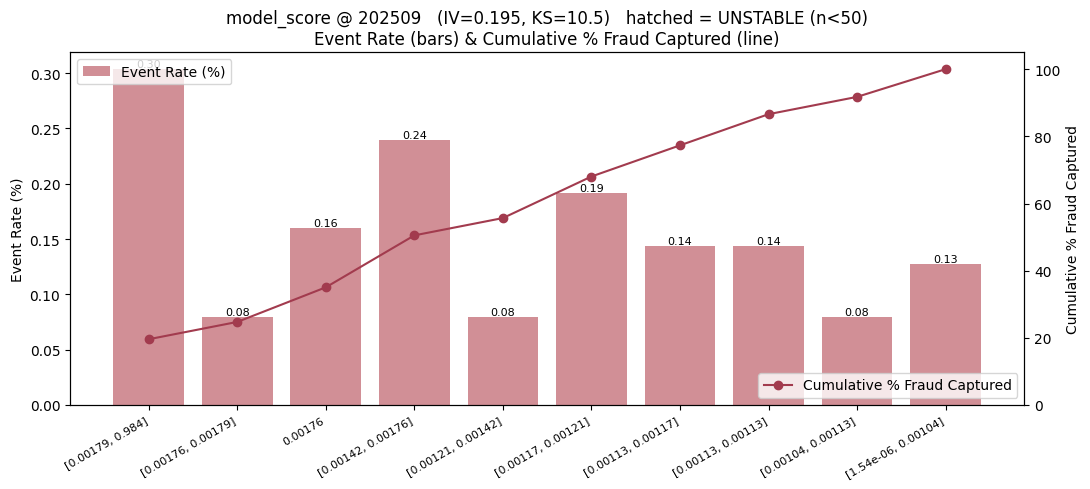

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[0.00179, 0.984]",19,6260,0.304,0.19,19.59,True
1,"[0.00176, 0.00179]",5,6260,0.080,0.03,24.74,True
2,0.00176,10,6259,0.160,0.09,35.05,True
3,"[0.00142, 0.00176]",15,6260,0.240,0.15,50.52,True
4,"[0.00121, 0.00142]",5,6259,0.080,0.03,55.67,True
5,"[0.00117, 0.00121]",12,6260,0.192,0.11,68.04,True
6,"[0.00113, 0.00117]",9,6260,0.144,0.08,77.32,True
7,"[0.00113, 0.00113]",9,6259,0.144,0.08,86.60,True
8,"[0.00104, 0.00113]",5,6260,0.080,0.03,91.75,True
9,"[1.54e-06, 0.00104]",8,6260,0.128,0.06,100.00,True


In [12]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import IPython.display as _disp
from pyspark.sql import functions as _F

CUST_TBL      = "payment_cards_dev.TP99965073_v2_scorecard_scores"
PLOT_FEATURES = ["model_score"]
PLOT_ANCHOR   = "202509"     # Sep = most matured; change to inspect another anchor
MIN_BIN_FRAC  = 0.01         # club any bin holding < 1% of customers into its neighbour
MIN_STABLE_CNT= 50           # bin with fewer customers than this is flagged UNSTABLE
MIN_STABLE_BAD= 5            # ...or fewer frauds than this
RISKY_ON_LEFT = True         # True = riskiest bin first (decile/gains look); False = feature-value order

def _wilson_lcb(bad, cnt, z=1.96):
    bad = np.asarray(bad, float); cnt = np.asarray(cnt, float)
    p = np.where(cnt > 0, bad / cnt, 0.0); denom = 1 + z*z/np.maximum(cnt, 1)
    centre = p + z*z/(2*np.maximum(cnt, 1)); margin = z*np.sqrt((p*(1-p) + z*z/(4*np.maximum(cnt,1)))/np.maximum(cnt,1))
    return np.where(cnt > 0, np.clip((centre - margin)/denom, 0, 1), 0.0)

def _robust_bins(x, max_bins=10):
    s = pd.Series(np.asarray(x, dtype=float)); nuniq = int(s.nunique(dropna=True))
    if nuniq <= 1: return np.zeros(len(s), dtype=int)
    if nuniq <= max_bins:
        order = {v: i for i, v in enumerate(sorted(s.dropna().unique()))}
        return s.map(order).fillna(0).astype(int).values
    z = (s == 0); out = np.zeros(len(s), dtype=int)
    if z.mean() >= 0.02 and int((~z).sum()) >= max_bins:
        pos = ~z
        qr = pd.qcut(s[pos].rank(method="first"), q=min(max_bins - 1, int((~z).sum())), labels=False, duplicates="drop")
        out[pos.values] = 1 + qr.astype(int).values; return out
    return pd.qcut(s.rank(method="first"), q=max_bins, labels=False, duplicates="drop").astype(int).values

def _club_sparse(d, n, min_frac):
    d = d.sort_index().copy()
    while len(d) > 2:
        share = d["cnt"] / n
        if share.min() >= min_frac: break
        j = int(share.values.argmin()); k = j + 1 if j == 0 else j - 1
        lo, hi = min(j, k), max(j, k)
        d.loc[d.index[lo], ["cnt", "bad"]] += d.loc[d.index[hi], ["cnt", "bad"]].values
        d.loc[d.index[lo], "hi"] = max(d.loc[d.index[lo], "hi"], d.loc[d.index[hi], "hi"])
        d.loc[d.index[lo], "lo"] = min(d.loc[d.index[lo], "lo"], d.loc[d.index[hi], "lo"])
        d = d.drop(d.index[hi]).reset_index(drop=True)
    return d

def _woe_iv(cnt, bad):
    good = cnt - bad; tb, tg = bad.sum(), good.sum()
    pb = (bad / tb).clip(lower=1e-6); pg = (good / tg).clip(lower=1e-6)
    return float(((pg - pb) * np.log(pg / pb)).sum())

_pdf = spark.table(CUST_TBL).where(_F.col("anchor_month") == PLOT_ANCHOR).select("target_fraud", *PLOT_FEATURES).toPandas()
_y = _pdf["target_fraud"].astype(int).values; _tot_bad = int(_y.sum()); _tot_good = len(_y) - _tot_bad
print("plotting anchor %s | customers=%d | frauds=%d" % (PLOT_ANCHOR, len(_pdf), _tot_bad))

def plot_sloping(feature):
    x = _pdf[feature].astype(float).values
    d = (pd.DataFrame({"b": _robust_bins(x), "x": x, "y": _y}).groupby("b")
         .agg(cnt=("y", "size"), bad=("y", "sum"), lo=("x", "min"), hi=("x", "max")).sort_index())
    d = _club_sparse(d, len(_pdf), MIN_BIN_FRAC)
    d = (d.iloc[::-1] if RISKY_ON_LEFT else d).reset_index(drop=True)
    d["event_rate_pct"] = 100.0 * d["bad"] / d["cnt"]
    cum_bad = d["bad"].cumsum(); cum_good = (d["cnt"] - d["bad"]).cumsum()
    d["pct_captured"] = 100.0 * cum_bad / max(_tot_bad, 1)
    ks = float((100.0 * cum_bad / max(_tot_bad, 1) - 100.0 * cum_good / max(_tot_good, 1)).abs().max())
    iv = _woe_iv(d["cnt"], d["bad"])
    d["er_lcb_pct"] = 100.0 * _wilson_lcb(d["bad"].values, d["cnt"].values)
    d["stable"] = (d["cnt"] >= MIN_STABLE_CNT) & (d["bad"] >= MIN_STABLE_BAD)
    labels = [("%.3g" % lo) if lo == hi else ("[%.3g, %.3g]" % (lo, hi)) for lo, hi in zip(d["lo"], d["hi"])]
    xs = range(len(d))
    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax1.bar(xs, d["event_rate_pct"], color="#c97b84", alpha=0.85, label="Event Rate (%)")
    for i, v in enumerate(d["event_rate_pct"]): ax1.text(i, v, "%.2f" % v, ha="center", va="bottom", fontsize=8)
    ax1.set_ylabel("Event Rate (%)"); ax1.set_xticks(list(xs)); ax1.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    for i, st in enumerate(d["stable"].values):
        if not st: ax1.patches[i].set_hatch("///"); ax1.patches[i].set_edgecolor("#7a2a34")
    ax2 = ax1.twinx()
    ax2.plot(xs, d["pct_captured"], color="#a23b4e", marker="o", label="Cumulative % Fraud Captured")
    ax2.set_ylabel("Cumulative % Fraud Captured"); ax2.set_ylim(0, 105)
    ax1.set_title("%s @ %s   (IV=%.3f, KS=%.1f)   hatched = UNSTABLE (n<%d)\nEvent Rate (bars) & Cumulative %% Fraud Captured (line)"
                  % (feature, PLOT_ANCHOR, iv, ks, MIN_STABLE_CNT), fontsize=12)
    ax1.legend(loc="upper left"); ax2.legend(loc="lower right"); fig.tight_layout(); plt.show()
    _disp.display(pd.DataFrame({"bin": labels, "# frauds": d["bad"].astype(int).values,
                                "# customers": d["cnt"].astype(int).values,
                                "event_rate_%": d["event_rate_pct"].round(3).values,
                                "event_rate_LCB_%": d["er_lcb_pct"].round(2).values,
                                "cum_%_captured": d["pct_captured"].round(2).values,
                                "stable": d["stable"].values}))

for _f in PLOT_FEATURES:
    try: plot_sloping(_f)
    except Exception as _e: print("  %s: skipped (%s)" % (_f, _e))
